# Cardiovascular Disease Prediction

 This project predicts cardiovascular disease risk using patient data like age, blood pressure, cholesterol, and lifestyle factors.

 I trained multiple machine learning models and selected Logistic Regression as it gave the highest accuracy.

 The model not only predicts disease occurrence but also calculates the probability (risk %) and categorizes risk into Low, Medium, or High. This helps in early intervention and personalized care.


# Data Pre-processing

The dataset was loaded and inspected for missing values. No null values were found. The unnecessary column id was removed because it does not contribute to prediction. The age feature was converted into years (if required). The dataset was then divided into input features and target variable. Finally, the data was split into training and testing sets.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
df = pd.read_csv("/content/cardio_train (1) file.csv")
df

,id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio
0,0;18393;2;168;62.0;110;80;1;1;0;0;1;0
1,1;20228;1;156;85.0;140;90;3;1;0;0;1;1
2,2;18857;1;165;64.0;130;70;3;1;0;0;0;1
3,3;17623;2;169;82.0;150;100;1;1;0;0;1;1
4,4;17474;1;156;56.0;100;60;1;1;0;0;0;0
...,...
69995,99993;19240;2;168;76.0;120;80;1;1;1;0;1;0
69996,99995;22601;1;158;126.0;140;90;2;2;0;0;1;1
69997,99996;19066;2;183;105.0;180;90;3;1;0;1;0;1
69998,99998;22431;1;163;72.0;135;80;1;2;0;0;0;1


In [56]:
df = pd.read_csv("/content/cardio_train (1) file.csv",sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [57]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [58]:
dp_val = df.duplicated().any()
dp_val

np.False_

In [59]:
df.shape

(70000, 13)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [61]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [62]:
df.drop("id",axis=1,inplace=True)

In [63]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


#Correlation Matrix

A correlation matrix was generated to analyze relationships among features. The heatmap visualization showed that age, blood pressure, and cholesterol are strongly correlated with cardiovascular disease.

In [64]:
df.corr()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330


Text(0.5, 1.0, 'Correlation Matrix')

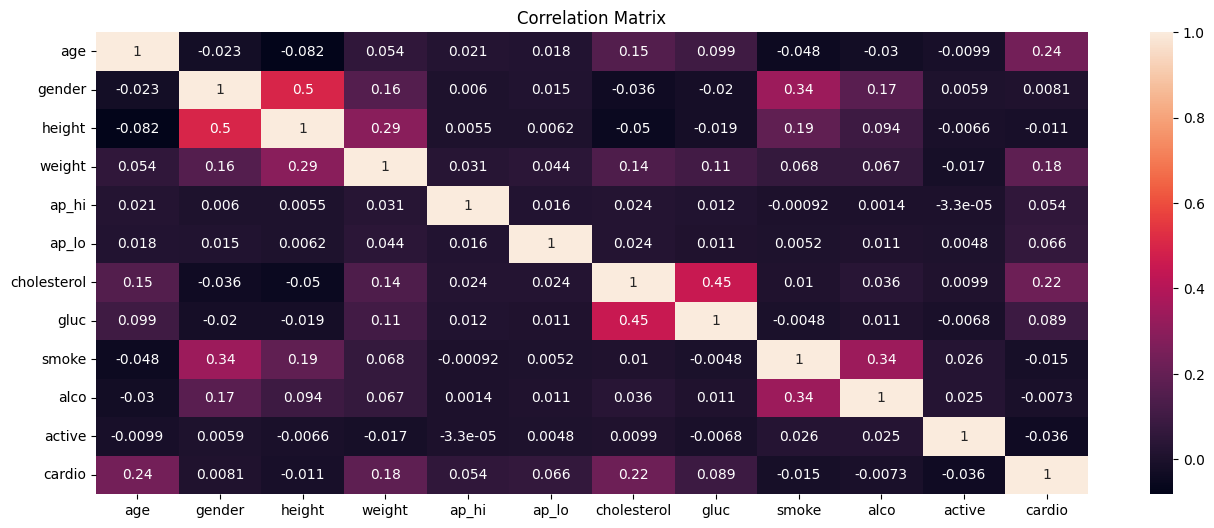

In [65]:
plt.figure(figsize=(16,6))
sns.heatmap(df.corr(),annot =True)
plt.title("Correlation Matrix")

In [66]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [67]:
df["cardio"].value_counts()

,count
cardio,
0,35021
1,34979


In [68]:
df['cardio'] = df['cardio'].map({0: 'No Disease', 1: 'Disease'})


/tmp/ipykernel_1247/335011863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df ,palette='pastel')


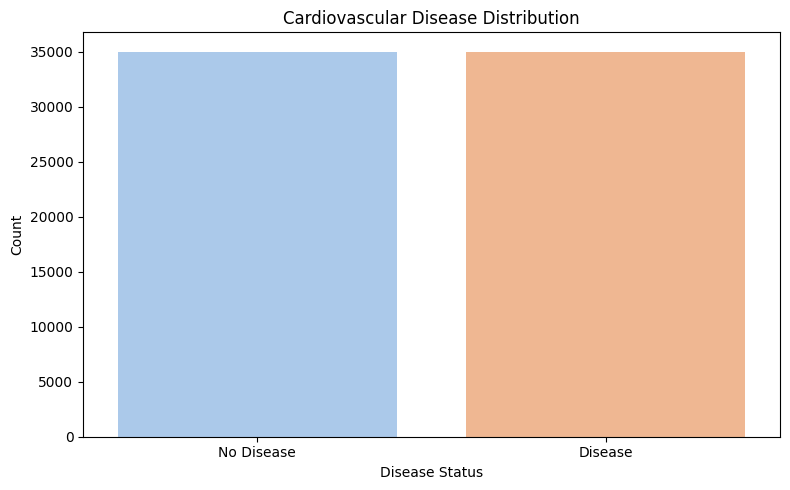

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(x='cardio', data=df ,palette='pastel')

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


# Data Analysis & Visualization

   Various graphs were plotted to understand the dataset and derive meaningful insights. These visualizations helped in identifying patterns and relationships between features and cardiovascular disease.

Observations:

  * Higher age,weight is associated with increased disease risk
  * Higher ap_hi,ap_lo shows strong relation with disease
  * Higher cholesterol,gluc levels increase risk

In [70]:
df["age"] = df["age"] / 365

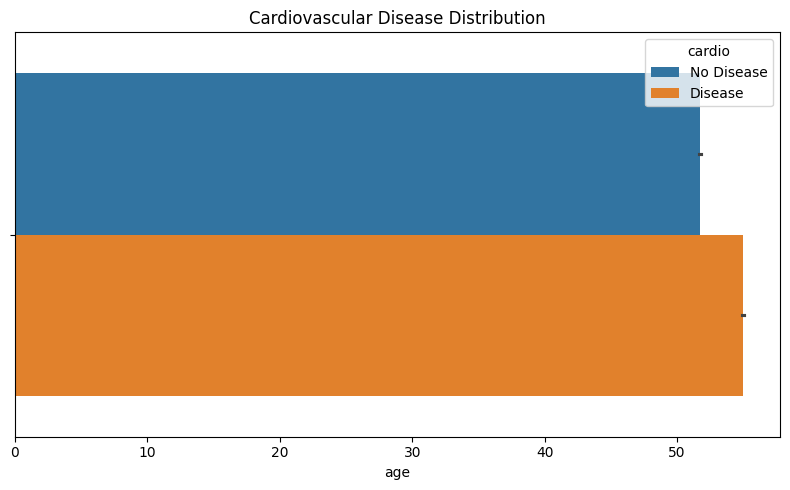

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(x='age', hue='cardio', data=df)
plt.title("Cardiovascular Disease Distribution")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


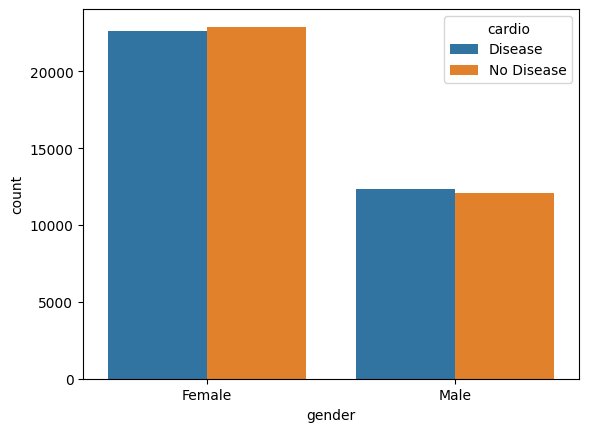

In [72]:
sns.countplot(x='gender',data=df, hue='cardio')
plt.xticks([0,1],['Female','Male'])
plt.show()

# Distplot / Age Distribution

A distribution plot was used to visualize the distribution of patient ages in the dataset. This plot shows how the age values are spread and helps identify the most common age group among patients. It also provides insights into whether cardiovascular disease risk is associated with increasing age.

/tmp/ipykernel_1247/1602346454.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'],bins=20)


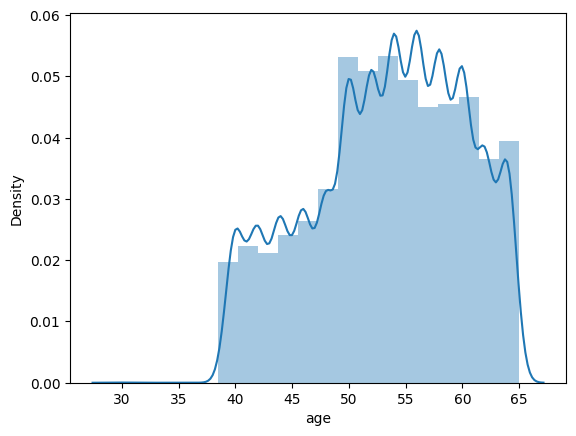

In [73]:
sns.distplot(df['age'],bins=20)
plt.show()

In [74]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

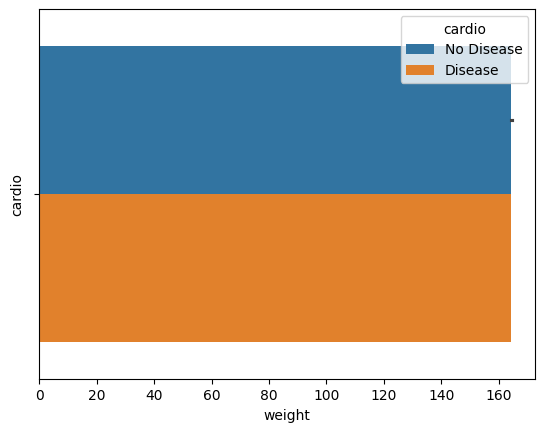

In [75]:
sns.barplot(x='height', hue ='cardio',data=df)
plt.xlabel("weight")
plt.ylabel("cardio")
plt.show()

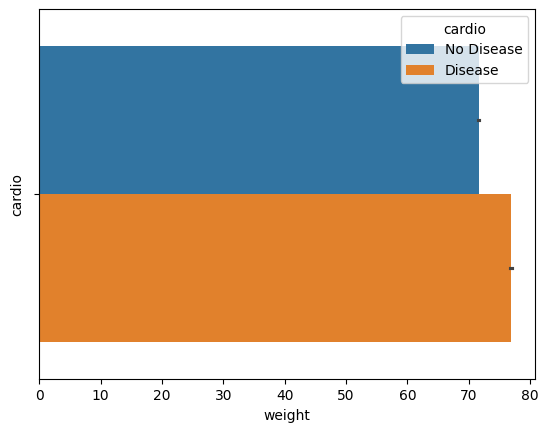

In [76]:
sns.barplot(x='weight', hue ='cardio',data=df)
plt.xlabel("weight")
plt.ylabel("cardio")
plt.show()

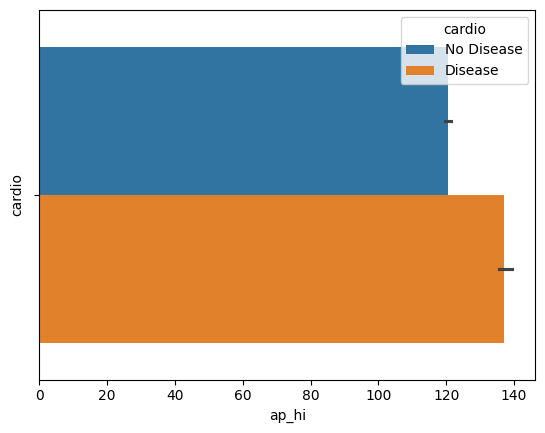

In [77]:
sns.barplot(x='ap_hi',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

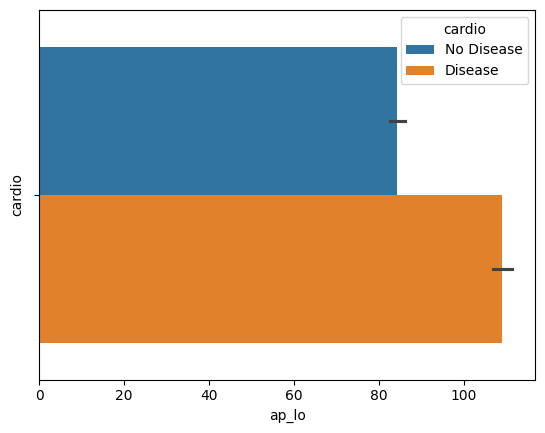

In [78]:
sns.barplot(x='ap_lo',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

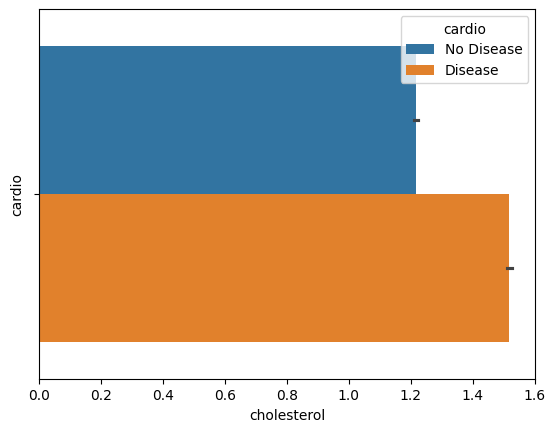

In [79]:
sns.barplot(x='cholesterol',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

In [80]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

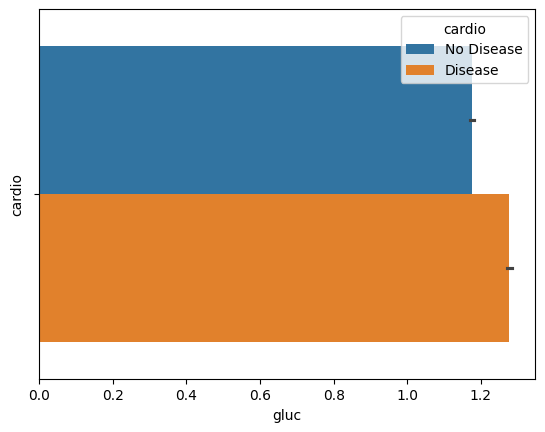

In [81]:
sns.barplot(x='gluc',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

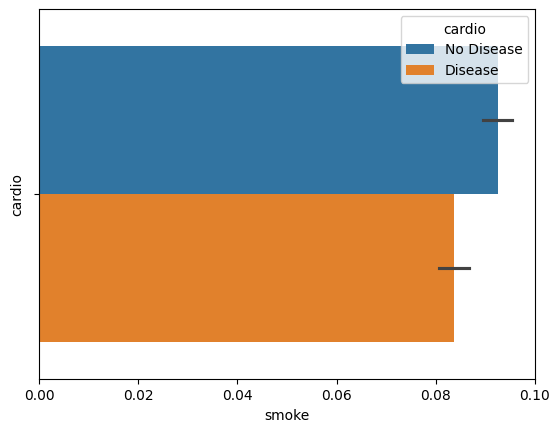

In [82]:
sns.barplot(x='smoke',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

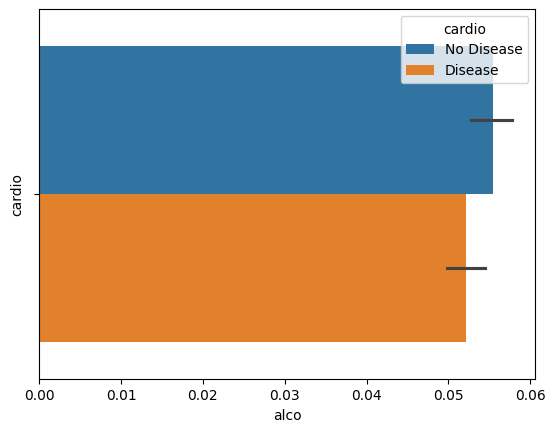

In [83]:
sns.barplot(x='alco',data=df, hue='cardio')
plt.ylabel("cardio")
plt.show()

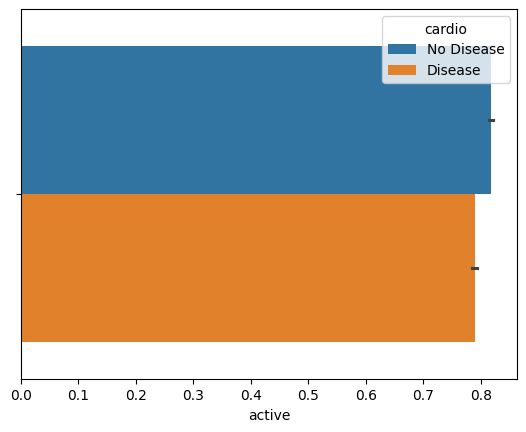

In [84]:
sns.barplot(x='active',data=df,hue='cardio')
plt.show()


# Machine Learning Models

Several machine learning algorithms were applied:

 * Logistic Regression

 * K-Nearest Neighbors (KNN)

 * Decision Tree

 * Random Forest


 * Support Vector Machine (SVM)

Each model was trained and tested, and accuracy scores were calculated.

In [85]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Accuracy Comparison

   Among all models, Logistic Regression achieved the highest accuracy of approximately 72%, making it the most effective model for this dataset.

In [87]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.7231428571428572


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [88]:
from sklearn.tree import DecisionTreeClassifier
dtc =  DecisionTreeClassifier()
dtc.fit(X_train,y_train)
print("Accuracy:",dtc.score(X_test,y_test))

Accuracy: 0.6321428571428571


In [89]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
print("Accuracy:",rfc.score(X_test,y_test))

Accuracy: 0.7148571428571429


In [90]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
print("Accuracy:",knn.score(X_test,y_test))

Accuracy: 0.6876428571428571


# Confusion Matrix

A confusion matrix was used to evaluate the model’s performance in detail. It shows correct and incorrect predictions and helps understand the types of errors made by the model.

In [91]:
y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))


[[4767 2245]
 [1631 5357]]


In [92]:
prob = model.predict_proba(X_test)

print(prob)

[[0.74647791 0.25352209]
 [0.82731619 0.17268381]
 [0.69749993 0.30250007]
 ...
 [0.43027797 0.56972203]
 [0.6643701  0.3356299 ]
 [0.57723968 0.42276032]]


In [93]:
import numpy as np

# Example patient details
# order should match your dataset features
# Example features: age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active

patient = np.array([[55, 1, 165, 70, 140, 90, 2, 1, 0, 0, 1]])

# Predict disease (0 or 1)
prediction = model.predict(patient)

# Predict probability
probability = model.predict_proba(patient)

risk = probability[0][1] * 100

print("Patient Details:")
print("Age: 55")
print("BP: 140/90")
print("Cholesterol: Above Normal")

print("\nPrediction Result")

if prediction[0] == 1:
    print("⚠️ Cardiovascular Disease Detected")
else:
    print("✅ No Cardiovascular Disease")

print(f"Risk Probability: {risk:.2f}%")

Patient Details:
Age: 55
BP: 140/90
Cholesterol: Above Normal

Prediction Result
✅ No Cardiovascular Disease
Risk Probability: 29.61%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [94]:
risk = probability[0][1]

if risk < 0.3:
    level = "Low Risk"
elif risk < 0.6:
    level = "Medium Risk"
else:
    level = "High Risk"

print(f"Risk Level: {level}")

Risk Level: Low Risk


This code takes basic patient details (Age, Blood Pressure, Cholesterol) and creates a data array matching the features used to train your Logistic Regression model.

model.predict() → predicts 0 (No Disease) or 1 (Disease Detected)

model.predict_proba() → gives probability of disease

The code then prints the risk percentage for the patient.

✅ In short: it predicts the chance of cardiovascular disease for a given patient.

In [95]:
age = int(input("Enter Age: "))
bp_high = int(input("Enter Systolic BP: "))
bp_low = int(input("Enter Diastolic BP: "))
chol = int(input("Cholesterol (1-normal,2-above normal,3-high): "))

patient = np.array([[age,1,165,70,bp_high,bp_low,chol,1,0,0,1]])

prediction = model.predict(patient)
prob = model.predict_proba(patient)[0][1] * 100

print("Predicted Risk:", prob,"%")

Enter Age: 50
Enter Systolic BP: 120
Enter Diastolic BP: 95
Cholesterol (1-normal,2-above normal,3-high): 3
Predicted Risk: 41.10564763339292 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



# Conclusion
 * Based on accuracy comparison, Logistic Regression was   selected  as the final model for predicting cardiovascular disease.

 * This project demonstrates how machine learning can be used to  predict cardiovascular disease using patient data. The model can assist healthcare professionals in early detection and prevention of heart disease.